## Задачи работы:

Цель — изучить метод обратного распространения ошибки для обучения глубоких нейронных сетей на примере двухслойной полносвязной нейронной сети (один скрытый слой)

## Проверка целостности данных:

Train: X=(60000, 784), y=(60000,)
Test : X=(10000, 784), y=(10000,)


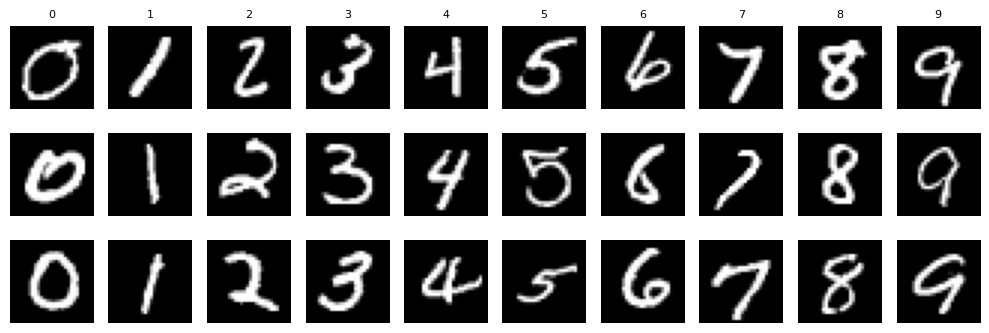

In [10]:
import os, gzip, struct, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import time

BASE_URL = "https://raw.githubusercontent.com/fgnt/mnist/master/"
FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images":  "t10k-images-idx3-ubyte.gz",
    "test_labels":  "t10k-labels-idx1-ubyte.gz",
}

def download_mnist(data_dir="mnist_data"):
    os.makedirs(data_dir, exist_ok=True)
    for name in FILES.values():
        path = os.path.join(data_dir, name)
        if not os.path.exists(path):
            print(f"Downloading {name}...")
            urllib.request.urlretrieve(BASE_URL + name, path)
    return data_dir

def load_mnist(data_dir="mnist_data"):
    def _read_images(fname):
        with gzip.open(os.path.join(data_dir, fname), "rb") as f:
            _, n, rows, cols = struct.unpack(">IIII", f.read(16))
            x = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)
        return x.astype(np.float32) / 255.0, (rows, cols)

    def _read_labels(fname):
        with gzip.open(os.path.join(data_dir, fname), "rb") as f:
            y = np.frombuffer(f.read(), dtype=np.uint8, offset=8)
        return y

    X_train, shape = _read_images(FILES["train_images"])
    y_train = _read_labels(FILES["train_labels"])
    X_test, _ = _read_images(FILES["test_images"])
    y_test = _read_labels(FILES["test_labels"])
    return X_train, y_train, X_test, y_test, shape

def show_samples(X, y, shape, n=4, seed=None):
    rng = np.random.default_rng(seed)
    fig, axs = plt.subplots(n, 10, figsize=(10, n * 1.2))

    for digit in range(10):
        indices = np.where(y == digit)[0]
        chosen_idx = rng.choice(indices, size=n, replace=False)

        for i in range(n):
            axs[i, digit].imshow(X[chosen_idx[i]].reshape(shape), cmap="gray")
            if i == 0:
                axs[i, digit].set_title(str(digit), fontsize=8)
            axs[i, digit].axis("off")

    plt.tight_layout()
    plt.show()

data_dir = download_mnist("mnist_data")
X_train, y_train, X_test, y_test, img_shape = load_mnist(data_dir)

print(f"Train: X={X_train.shape}, y={y_train.shape}")
print(f"Test : X={X_test.shape}, y={y_test.shape}")

show_samples(X_train, y_train, img_shape, n=3, seed=42)

## Выполнение one-hot кодирования:

In [13]:
def one_hot(y, num_classes=10):
    encoded = np.zeros((len(y), num_classes))
    for i in range(len(y)):
        encoded[i, y[i]] = 1
    return encoded

Y_train = one_hot(y_train)
Y_test = one_hot(y_test)

## Теория:

# Forward and Backpropagation (Mini-batch = 32)

## Первый слой (Прямой проход)

$$
Z^{(1)} = XW^{(1)} + b^{(1)}
$$

$$
A^{(1)} = \mathrm{ReLU}(Z^{(1)})
$$

------------------------------------------------------------------------

## Второй слой (Прямой проход)

$$
Z^{(2)} = A^{(1)}W^{(2)} + b^{(2)}
$$

$$
A^{(2)} = \mathrm{softmax}(Z^{(2)})
$$

------------------------------------------------------------------------

## Функция потерь (Cross-Entropy)

$$
E = -\frac{1}{32}
\sum_{m=1}^{32}
\sum_{j=1}^{10}
y_{m,j}\log a^{(2)}_{m,j}
$$

------------------------------------------------------------------------

# Обратное распространение ошибки

## Градиенты второго слоя

Из softmax + cross-entropy:

$$
dZ^{(2)} = A^{(2)} - Y
$$

$$
\frac{\partial E}{\partial W^{(2)}} =
\frac{(A^{(1)})^T dZ^{(2)}}{32}
$$

$$
\frac{\partial E}{\partial b^{(2)}} =
\frac{1}{32}
\sum_{m=1}^{32}
dZ^{(2)}_{m,:}
$$

------------------------------------------------------------------------

## Градиенты первого слоя

$$
dA^{(1)} = dZ^{(2)} (W^{(2)})^T
$$

$$
dZ^{(1)} =
dA^{(1)} \odot \mathrm{ReLU}'(Z^{(1)})
$$

$$
\frac{\partial E}{\partial W^{(1)}} =
\frac{X^T dZ^{(1)}}{32}
$$

$$
\frac{\partial E}{\partial b^{(1)}} =
\frac{1}{32}
\sum_{m=1}^{32}
dZ^{(1)}_{m,:}
$$

------------------------------------------------------------------------

# Обновение параметров

$$
\theta =
\theta - \alpha \nabla_{\theta} E
$$

где

$$
\theta = \{W^{(1)}, b^{(1)}, W^{(2)}, b^{(2)}\}
$$


# Softmax + Cross-Entropy

## Softmax определение

$$
a_i = \frac{e^{z_i}}{\sum_{k=1}^{10} e^{z_k}}
$$

------------------------------------------------------------------------

## Softmax производная

Для всех $i, j$:

$$
\frac{\partial a_i}{\partial z_j}
=
\begin{cases}
a_i (1 - a_i), & i = j \\
- a_i a_j, & i \neq j
\end{cases}
$$

Или компактно:

$$
\frac{\partial a_i}{\partial z_j}
=
a_i (\delta_{ij} - a_j)
$$

где $\delta_{ij}$ - символ Кронекера.

------------------------------------------------------------------------

# Cross-Entropy

$$
E = - \sum_{k=1}^{10} y_k \log(a_k)
$$

------------------------------------------------------------------------

# Производная функции потерь

по цепочке:

$$
\frac{\partial E}{\partial z_i}
=
- \sum_{k=1}^{10}
\frac{y_k}{a_k}
\frac{\partial a_k}{\partial z_i}
$$

Подставляя производную функции softmax и разделяя случаи $k=i$ и
$k\neq i$, выражение упрощается до:

$$
\frac{\partial E}{\partial z_i}
= a_i - y_i
$$

------------------------------------------------------------------------

# Конечный результат

$$
\nabla_{z} E = a - y
$$

Поэтому сочетание функции softmax с кросс-энтропией приводит к простому выражению градиента


## Реализация нейронной сети:

Epoch 1: Train acc 0.9499, loss 0.1742 | Test acc 0.9461, loss 0.1764 (6.35s)
Epoch 2: Train acc 0.9735, loss 0.0957 | Test acc 0.9682, loss 0.1066 (5.80s)
Epoch 3: Train acc 0.9801, loss 0.0748 | Test acc 0.9711, loss 0.0986 (5.26s)
Epoch 4: Train acc 0.9860, loss 0.0539 | Test acc 0.9765, loss 0.0778 (5.86s)
Epoch 5: Train acc 0.9875, loss 0.0464 | Test acc 0.9762, loss 0.0750 (5.29s)
Epoch 6: Train acc 0.9907, loss 0.0371 | Test acc 0.9791, loss 0.0692 (5.33s)
Epoch 7: Train acc 0.9919, loss 0.0312 | Test acc 0.9791, loss 0.0648 (5.79s)
Epoch 8: Train acc 0.9934, loss 0.0264 | Test acc 0.9801, loss 0.0650 (5.25s)
Epoch 9: Train acc 0.9954, loss 0.0221 | Test acc 0.9820, loss 0.0617 (5.22s)
Epoch 10: Train acc 0.9961, loss 0.0205 | Test acc 0.9792, loss 0.0638 (5.67s)
Epoch 11: Train acc 0.9979, loss 0.0144 | Test acc 0.9823, loss 0.0575 (5.70s)
Epoch 12: Train acc 0.9979, loss 0.0133 | Test acc 0.9819, loss 0.0569 (5.37s)
Epoch 13: Train acc 0.9986, loss 0.0110 | Test acc 0.9821, lo

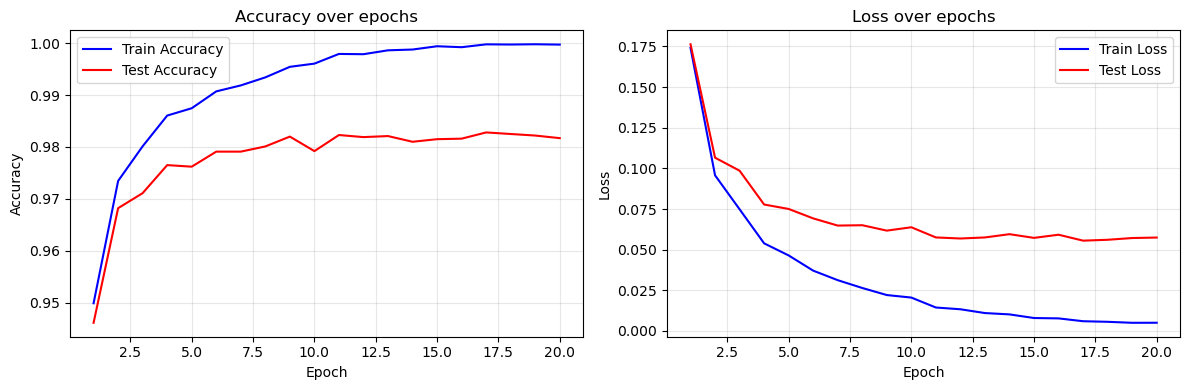

In [20]:
def init_params(input_size, hidden_size, output_size):
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2./input_size)
    b1 = np.zeros(hidden_size)
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2./hidden_size)
    b2 = np.zeros(output_size)
    return W1, b1, W2, b2

def relu(z, deriv=False):
    return (z > 0).astype(float) if deriv else np.maximum(0, z)

def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def forward(X, W1, b1, W2, b2):
    z1 = X @ W1 + b1
    a1 = relu(z1)
    z2 = a1 @ W2 + b2
    a2 = softmax(z2)
    return a2, (z1, a1)

def backprop(X, y, a2, cache, W2):
    z1, a1 = cache
    m = X.shape[0]
    
    dz2 = a2 - y
    dW2 = a1.T @ dz2 / m
    db2 = dz2.mean(axis=0)
    
    da1 = dz2 @ W2.T
    dz1 = da1 * relu(z1, deriv=True)
    dW1 = X.T @ dz1 / m
    db1 = dz1.mean(axis=0)
    
    return dW1, db1, dW2, db2

def compute_loss_acc(X, y_onehot, y_labels, W1, b1, W2, b2):
    a2, _ = forward(X, W1, b1, W2, b2)
    loss = -np.sum(y_onehot * np.log(a2 + 1e-9)) / X.shape[0]
    acc = np.mean(np.argmax(a2, axis=1) == y_labels)
    return loss, acc

def plot_training(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    epochs = range(1, len(history['train_acc']) + 1)
    
    # accuracy
    ax1.plot(epochs, history['train_acc'], 'b-', label='Train Accuracy')
    ax1.plot(epochs, history['test_acc'], 'r-', label='Test Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.set_title('Accuracy over epochs')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # loss
    ax2.plot(epochs, history['train_loss'], 'b-', label='Train Loss')
    ax2.plot(epochs, history['test_loss'], 'r-', label='Test Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.set_title('Loss over epochs')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def train(X, Y, y_labels, X_test, Y_test, y_test_labels, hidden_size=300, lr=0.1, batch_size=32, epochs=20):
    input_size, output_size = X.shape[1], Y.shape[1]
    W1, b1, W2, b2 = init_params(input_size, hidden_size, output_size)
    
    history = {
        'train_acc': [],
        'train_loss': [],
        'test_acc': [],
        'test_loss': []
    }
    
    for epoch in range(epochs):
        start = time.time()
        perm = np.random.permutation(X.shape[0])
        X_shuf, Y_shuf = X[perm], Y[perm]
        
        for i in range(0, X.shape[0], batch_size):
            Xb = X_shuf[i:i+batch_size]
            Yb = Y_shuf[i:i+batch_size]
            
            a2, cache = forward(Xb, W1, b1, W2, b2)
            grads = backprop(Xb, Yb, a2, cache, W2)
            
            W1 -= lr * grads[0]
            b1 -= lr * grads[1]
            W2 -= lr * grads[2]
            b2 -= lr * grads[3]
        
        train_loss, train_acc = compute_loss_acc(X, Y, y_labels, W1, b1, W2, b2)
        test_loss, test_acc = compute_loss_acc(X_test, Y_test, y_test_labels, W1, b1, W2, b2)
        
        history['train_acc'].append(train_acc)
        history['train_loss'].append(train_loss)
        history['test_acc'].append(test_acc)
        history['test_loss'].append(test_loss)
        
        print(f"Epoch {epoch+1}: Train acc {train_acc:.4f}, loss {train_loss:.4f} | Test acc {test_acc:.4f}, loss {test_loss:.4f} ({time.time()-start:.2f}s)")
    
    plot_training(history)
    
    return W1, b1, W2, b2

# Использование:
W1, b1, W2, b2 = train(X_train, Y_train, y_train, X_test, Y_test, y_test, 
                        hidden_size=300, lr=0.1, batch_size=32, epochs=20)

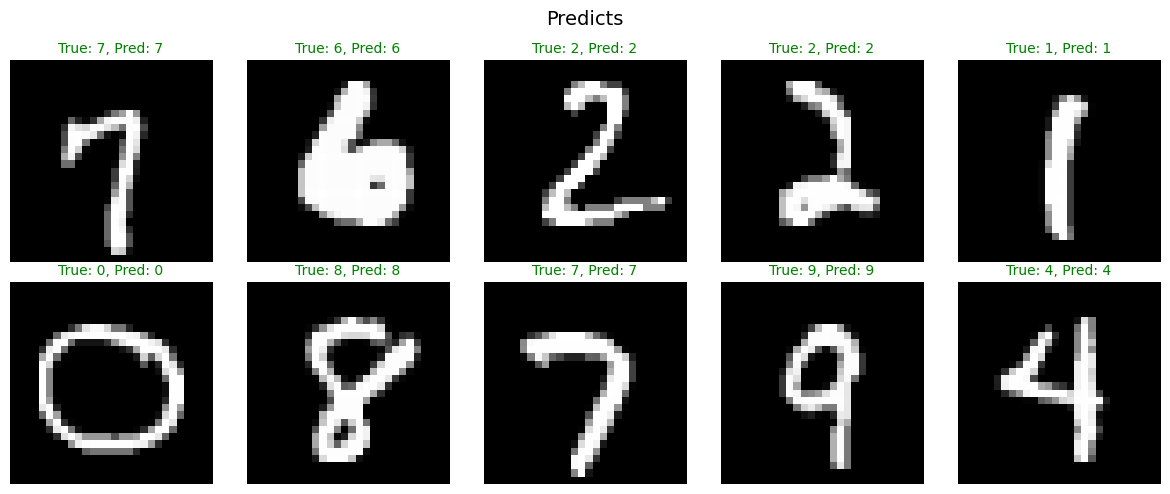

In [21]:
def show_predictions(X, y_true, W1, b1, W2, b2, n_samples=10, seed=None):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(X), size=n_samples, replace=False)
    
    fig, axs = plt.subplots(2, 5, figsize=(12, 5))
    axs = axs.flatten()
    
    for i, idx in enumerate(indices):
        a2, _ = forward(X[idx:idx+1], W1, b1, W2, b2)
        pred = np.argmax(a2[0])
        true = y_true[idx]
        
        axs[i].imshow(X[idx].reshape(28, 28), cmap='gray')
        
        color = 'green' if pred == true else 'red'
        axs[i].set_title(f'True: {true}, Pred: {pred}', color=color, fontsize=10)
        axs[i].axis('off')
    
    plt.suptitle('Predicts', fontsize=14)
    plt.tight_layout()
    plt.show()

show_predictions(X_test, y_test, W1, b1, W2, b2, n_samples=10, seed=42)